In [494]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from utils import *
from sklearn.preprocessing import StandardScaler
import importlib
import LogisticRegression as LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [495]:
#read the dataset
df = pd.read_csv("dataset/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [496]:
# Check for duplicates in the dataset
df.duplicated().sum()

np.int64(1202)

In [497]:
# View the duplicate rows to understand which entries are repeated and if they need to be addressed (e.g., by removing or consolidating them).
df[df.duplicated(keep=False)].sort_values(
    by=["name", "year"]
).head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1977,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
7324,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
2129,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
7775,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
131,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1561,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1857,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
3236,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
5245,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
7699,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


In [498]:
#Since they are completely identical, we can drop the duplicates to avoid biasing our model with repeated data points.
df = df.drop_duplicates()

In [499]:
# Check the distribution of the 'owner' column
df['owner'].value_counts()

owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

In [500]:
# Map the 'owner' column to numerical values
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df["owner"] = df["owner"].map(owner_mapping)

In [501]:
#display the first few rows of the DataFrame to verify the changes
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [502]:
# Check the distribution of the 'owner' column to ensure the mapping was successful
df['owner'].value_counts()

owner
1    4242
2    1974
3     536
4     169
5       5
Name: count, dtype: int64

In [503]:
# Check the unique values in the 'fuel' column
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [504]:
# Remove rows with specific fuel types, as they use a different mileage system
remove_values = ["CNG", "LPG"]
df = df[~df["fuel"].isin(remove_values)]

In [505]:
# Check the unique values in the 'fuel' column after removing the specified fuel types
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

In [506]:
# Check the first few rows of the 'mileage' column and its data type
print(df["mileage"].head())
print(df["mileage"].dtype)

0     23.4 kmpl
1    21.14 kmpl
2     17.7 kmpl
3     23.0 kmpl
4     16.1 kmpl
Name: mileage, dtype: str
str


In [507]:
# Check for missing values in the 'mileage' column
df["mileage"].isna().sum()

np.int64(201)

In [508]:
# Display rows with missing values in the 'mileage' column
# do not handle the NaN value yet. just display the rows with NaN values in the mileage column to understand the data better.
df[df["mileage"].isnull()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
13,Maruti Swift 1.3 VXi,2007,200000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
31,Fiat Palio 1.2 ELX,2003,70000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
78,Tata Indica DLS,2003,50000,70000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN
87,Maruti Swift VDI BSIV W ABS,2015,475000,78000,Diesel,Dealer,Manual,1,NaN,NaN,NaN,NaN,NaN
119,Maruti Swift VDI BSIV,2010,300000,120000,Diesel,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7740,Hyundai Santro Xing XG,2004,70000,70000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
7996,Hyundai Santro LS zipPlus,2000,140000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8009,Hyundai Santro Xing XS eRLX Euro III,2006,145000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8068,Ford Figo Aspire Facelift,2017,580000,165000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN


In [509]:
# Check the shape of the DataFrame
df.shape

(6832, 13)

In [510]:
# Convert the 'mileage' column to float by extracting the numeric part and converting it to float
df["mileage"] = df.mileage.str.split().str[0].astype(float)

In [511]:
# Check the first few rows of the 'mileage' column and its data type to see if the conversion was successful
print(df["mileage"].head())
print(df["mileage"].dtype)

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64
float64


In [512]:
# Convert the 'engine' column to float by extracting the numeric part and converting it to float
df["engine"] = df.engine.str.split().str[0].astype(float)

In [513]:
# Check the first few rows of the 'engine' column and its data type to see if the conversion was successful
print(df["engine"].head())
print(df["engine"].dtype)

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64
float64


In [514]:
# Convert the 'max_power' column to float by extracting the numeric part and converting it to float
df["max_power"] = df["max_power"].str.split().str[0].astype(float)

In [515]:
#  Check the first few rows of the 'max_power' column and its data type to see if the conversion was successful
print(df["max_power"].head())
print(df["max_power"].dtype)

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64
float64


In [516]:
# Check the first few rows of the 'name' column and its data type

print(df["name"].head())
print(df["name"].dtype)

0          Maruti Swift Dzire VDI
1    Skoda Rapid 1.5 TDI Ambition
2        Honda City 2017-2020 EXi
3       Hyundai i20 Sportz Diesel
4          Maruti Swift VXI BSIII
Name: name, dtype: str
str


In [517]:
# Split the 'name' column to extract the first word (brand name) and assign it back to the 'name' column
df["name"] = df["name"].str.split().str[0]

In [518]:
# Check the first few rows of the 'name' column and its data type to see if the conversion was successful
print(df["name"].head())
print(df["name"].dtype)

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: object
object


In [519]:
# Drop the 'torque' column from the DataFrame, as it may not be relevant for the analysis or model training
df = df.drop("torque", axis=1)

In [520]:
# Check the columns of the DataFrame to verify the changes
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

In [521]:
# Remove rows where the 'owner' column has a value of 5 (Test Drive Car), as they are ridiculously expensive
df = df[df["owner"] != 5]

In [522]:
# Check the distribution of the 'owner' column after removing the rows with 'Test Drive Car' to ensure the changes were successful
df['owner'].value_counts()

owner
1    4191
2    1943
3     528
4     165
Name: count, dtype: int64

In [523]:
# Check for any remaining missing values in the DataFrame
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
dtype: int64

In [524]:
# Check the shape of the DataFrame after all the preprocessing steps
df.shape

(6827, 12)

In [525]:
#There are 8,028 rows (samples) and 12 columns (features + target)
#We have 214 rows with missing values in some columns, which is only about 2.7% of the dataset. 
# I think it is reasonable to remove these rows since we would still retain about 97.3% of the data.
df = df.dropna()

In [526]:
#check if there are any missing values left
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [527]:
# Display the selling price column from the dataframe
df["selling_price"]

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000
8125    382000
Name: selling_price, Length: 6626, dtype: int64

In [528]:
# Make a copy of the selling price column to preserve the original values
df["original_price"] = df["selling_price"].copy()

# Define the bins for categorizing the selling price
bins = [0, 250000, 500000, 1000000, np.inf]

# Categorize the selling price into bins
df["selling_price"] = pd.cut(
    df["original_price"],
    bins=bins,
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

In [529]:
# Display the value counts of the categorized selling price
df["selling_price"].value_counts().sort_index()

selling_price
0    1705
1    2305
2    2147
3     469
Name: count, dtype: int64

In [530]:

# Display the summary statistics of the original selling price
print(df["original_price"].describe())

count    6.626000e+03
mean     5.267331e+05
std      5.116099e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.220000e+05
75%      6.500000e+05
max      1.000000e+07
Name: original_price, dtype: float64


In [531]:
# Display the price range of each bin
df.groupby("selling_price").agg(
    min_price=("original_price", "min"),
    max_price=("original_price", "max"),
    count=("original_price", "count")
)

,min_price,max_price,count
selling_price,,,
0,29999,250000,1705
1,250999,500000,2305
2,501000,1000000,2147
3,1019999,10000000,469


In [532]:
# Display the column names of the dataframe
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'original_price'],
      dtype='str')

In [533]:
# Define the feature columns and target variable for the model
feature_columns = [
    "name",
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Split the data into features (X) and target variable (y)
X = df[feature_columns]
y = df['selling_price']



In [534]:

# Display the value counts of the selling price
print(df["selling_price"].value_counts().sort_index())


selling_price
0    1705
1    2305
2    2147
3     469
Name: count, dtype: int64


In [535]:
#Split the dataset into training and testing sets, with 80% of the data used for training and 20% for testing. The random_state parameter is set to 42 to ensure reproducibility of the results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,  stratify=y
)

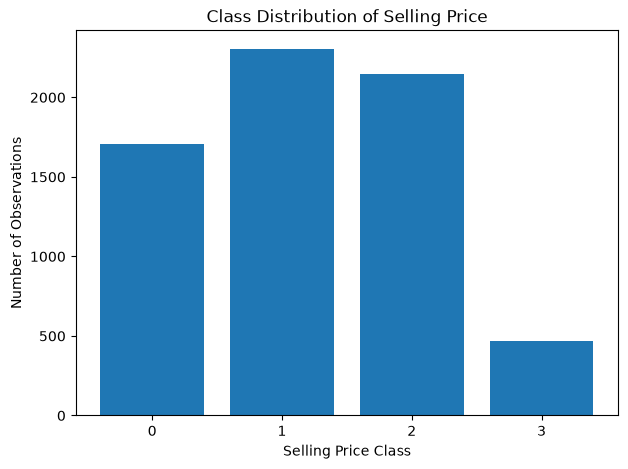

In [536]:
# Plot the class distribution of the selling price
class_counts = df["selling_price"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Selling Price Class")
plt.ylabel("Number of Observations")
plt.title("Class Distribution of Selling Price")

plt.xticks([0, 1, 2, 3])
plt.show()

In [537]:
# Check the first few rows of the training set to ensure that the split was successful and the data looks as expected
X_train.head()

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
1041,Honda,2016,100000,Diesel,Individual,Manual,2,24.20,1498.0,98.60,7.0
7224,Toyota,2009,220000,Diesel,Individual,Manual,1,12.80,2494.0,102.00,8.0
1983,Maruti,2019,4875,Petrol,Dealer,Manual,1,21.63,998.0,67.04,5.0
7424,Maruti,2012,112048,Petrol,Individual,Manual,2,17.50,1298.0,85.80,5.0
158,Mercedes-Benz,2017,16000,Petrol,Dealer,Automatic,1,14.74,1991.0,181.04,5.0


In [538]:
# Define the categorical features that need to be one-hot encoded
categorical_features = [
    "name",
    "fuel",
    "seller_type",
    "transmission"
]

# Create a ColumnTransformer to apply one-hot encoding to the categorical features while leaving the other features unchanged
# It is needed since the model cannot handle categorical features directly, and one-hot encoding is a common technique to convert categorical variables into a format that can be provided to machine learning algorithms to do a better job in prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)
# FIT the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Only TRANSFORM test data
X_test_processed = preprocessor.transform(X_test)

In [539]:
# Reload the LogisticRegression module to ensure the latest changes are applied
LogisticRegression = importlib.reload(LogisticRegression)

In [540]:
# Standardize the processed training and test data
X_train_processed = X_train_processed.toarray()
X_test_processed = X_test_processed.toarray()
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)


In [541]:
# make sure our y is in the shape of (m, k)
# we will convert our output vector in 
# matrix where no. of columns is equal to the no. of classes. 
# The values in the matrix will be 0 or 1. For instance the rows 
# where we have output 2 the column 2 will contain 1 and the rest are all 0.
# in simple words, y will be of shape (m, k)
k = len(set(y))  # no. of class  (can also use np.unique)
m = X_train_scaled.shape[0]  # no.of samples
n = X_train_scaled.shape[1]  # no. of features
Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train==each_class
    Y_train_encoded[np.where(cond), each_class] = 1

Loss at iteration 0: 1.393139
Loss at iteration 500: 1.223842
Loss at iteration 1000: 1.140394
Loss at iteration 1500: 1.074400
Loss at iteration 2000: 1.045070
Loss at iteration 2500: 1.000144
Loss at iteration 3000: 0.990340
Loss at iteration 3500: 0.973410
Loss at iteration 4000: 0.972556
Loss at iteration 4500: 0.959237
Time taken: 19.63 seconds


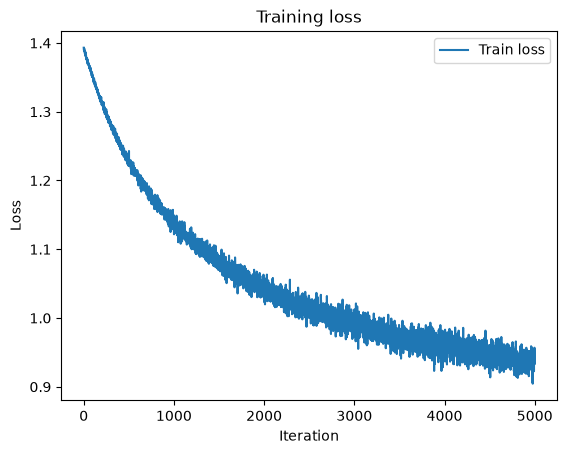

===== Per-class metrics =====
Accuracy: 0.6432880844645551
Class 0: precision=0.6404, recall=0.9296, f1=0.7584
Class 1: precision=0.7539, recall=0.3124, f1=0.4417
Class 2: precision=0.6796, recall=0.7744, f1=0.7239
Class 3: precision=0.3933, recall=0.6277, f1=0.4836
\n===== Macro metrics =====
Macro precision: 0.6168139780106872
Macro recall: 0.6610153431525958
Macro F1: 0.6019026495019949
\n===== Weighted metrics =====
Assignment weighted precision: 0.16876617841838487
Assignment weighted recall: 0.16082202111613877
Assignment weighted F1: 0.15440776585359733
Standard weighted precision: 0.6750647136735395
Standard weighted recall: 0.6432880844645551
Standard weighted F1: 0.6176310634143893
\n===== scikit-learn classification report =====
              precision    recall  f1-score   support

           0       0.64      0.93      0.76       341
           1       0.75      0.31      0.44       461
           2       0.68      0.77      0.72       430
           3       0.39      0.63

In [542]:
# ----- Task 1: ordinary multinomial logistic regression -----
# Train and evaluate an ordinary multinomial logistic regression model for car price classification
model = LogisticRegression.LogisticRegression(
    k=k, n=X_train_scaled.shape[1], method="minibatch",
    alpha=0.001, max_iter=5000, use_ridge=False
)

# Fit the model to the training data and make predictions on the test data
model.fit(X_train_scaled, Y_train_encoded)
yhat = model.predict(X_test_scaled)
model.plot()

# Save the trained model, preprocessor, and scaler for future use
save("models/car_price_classification_model.pkl", model)
save("models/car_price_classification_preprocessor.pkl", preprocessor)
save("models/car_price_classification_scaler.pkl", scaler)

print("===== Per-class metrics =====")
print("Accuracy:", model.accuracy(y_test, yhat))
for c in range(k):
    print(
        f"Class {c}: "
        f"precision={model.precision(y_test, yhat, c):.4f}, "
        f"recall={model.recall(y_test, yhat, c):.4f}, "
        f"f1={model.f1_score(y_test, yhat, c):.4f}"
    )

print("\\n===== Macro metrics =====")
print("Macro precision:", model.macro_precision(y_test, yhat))
print("Macro recall:", model.macro_recall(y_test, yhat))
print("Macro F1:", model.macro_f1(y_test, yhat))

print("\\n===== Weighted metrics =====")
print("Assignment weighted precision:", model.weighted_precision(y_test, yhat))
print("Assignment weighted recall:", model.weighted_recall(y_test, yhat))
print("Assignment weighted F1:", model.weighted_f1(y_test, yhat))
print("Standard weighted precision:", model.weighted_precision_standard(y_test, yhat))
print("Standard weighted recall:", model.weighted_recall_standard(y_test, yhat))
print("Standard weighted F1:", model.weighted_f1_standard(y_test, yhat))

print("\\n===== scikit-learn classification report =====")
print(classification_report(y_test, yhat, labels=np.arange(k), zero_division=0))


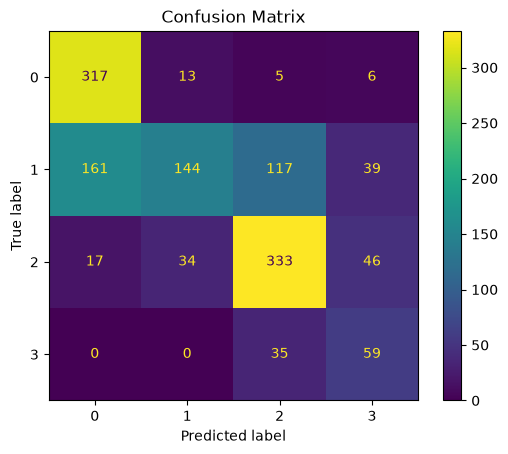

In [543]:
# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_test, yhat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [544]:
# ----- Task 2: Ridge / L2-regularized multinomial logistic regression -----
# Generate and display the confusion matrix for the ridge model predictions
ridge_model = LogisticRegression.LogisticRegression(
    k=k, n=X_train_scaled.shape[1], method="minibatch",
    alpha=0.001, max_iter=5000,
    use_ridge=True, lambda_=0.1
)

# Fit the ridge model to the training data
ridge_model.fit(X_train_scaled, Y_train_encoded)
ridge_yhat = ridge_model.predict(X_test_scaled)
# Save the ridge model for future use
save("models/car_price_classification_ridge_model.pkl", ridge_model)

print("Ridge accuracy:", ridge_model.accuracy(y_test, ridge_yhat))
print("Ridge macro precision:", ridge_model.macro_precision(y_test, ridge_yhat))
print("Ridge macro recall:", ridge_model.macro_recall(y_test, ridge_yhat))
print("Ridge macro F1:", ridge_model.macro_f1(y_test, ridge_yhat))
print("Ridge standard weighted precision:",
      ridge_model.weighted_precision_standard(y_test, ridge_yhat))
print("Ridge standard weighted recall:",
      ridge_model.weighted_recall_standard(y_test, ridge_yhat))
print("Ridge standard weighted F1:",
      ridge_model.weighted_f1_standard(y_test, ridge_yhat))

print("\\n===== Ridge scikit-learn classification report =====")
print(classification_report(
    y_test, ridge_yhat, labels=np.arange(k), zero_division=0
))


Loss at iteration 0: 1.383915
Loss at iteration 500: 1.235994
Loss at iteration 1000: 1.170525
Loss at iteration 1500: 1.136514
Loss at iteration 2000: 1.114714
Loss at iteration 2500: 1.113492
Loss at iteration 3000: 1.096090
Loss at iteration 3500: 1.098713
Loss at iteration 4000: 1.085477
Loss at iteration 4500: 1.109164
Time taken: 14.60 seconds
Ridge accuracy: 0.6312217194570136
Ridge macro precision: 0.604164284522389
Ridge macro recall: 0.6603729565272491
Ridge macro F1: 0.5931784212122072
Ridge standard weighted precision: 0.661666493629673
Ridge standard weighted recall: 0.6312217194570136
Ridge standard weighted F1: 0.6057676853233815
\n===== Ridge scikit-learn classification report =====
              precision    recall  f1-score   support

           0       0.64      0.93      0.76       341
           1       0.72      0.30      0.43       461
           2       0.68      0.74      0.71       430
           3       0.38      0.67      0.48        94

    accuracy        

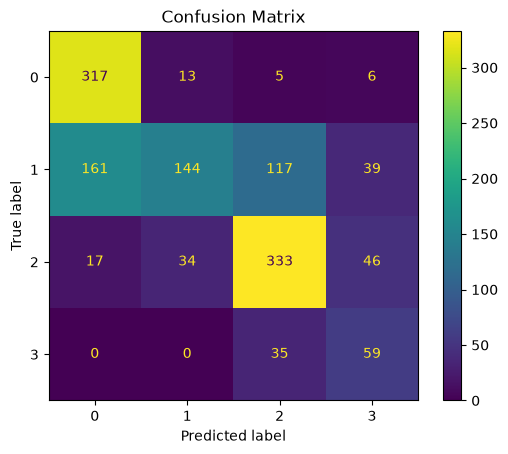

In [545]:

# Generate and display the confusion matrix for the ordinary multinomial logistic regression model predictions
cm = confusion_matrix(y_test, yhat)
# Compute the confusion matrix for the ordinary multinomial logistic regression model predictions
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

The standard Multinomial Logistic Regression model achieved an accuracy of 64.33%, a macro F1-score of 60.19%, and a weighted F1-score of 61.76%. The Ridge Logistic Regression model with λ = 0.1 achieved an accuracy of 63.12%, a macro F1-score of 59.32%, and a weighted F1-score of 60.58%. Therefore, under the current experimental settings, the standard Logistic Regression model achieved slightly higher overall classification performance than the Ridge-regularized model.
The macro recall of the two models was almost identical, with 66.10% for the standard model and 66.04% for the Ridge model. The Ridge model achieved a slightly higher recall for Class 3 (66.67% compared with 62.77%), but its recall for Classes 1 and 2 was lower. Overall, the Ridge regularization with λ = 0.1 did not improve the model's accuracy, macro F1, or weighted F1 in this experiment.